# Exercise 2

You are allowed to use the folowing functions and classes from `torch.nn`: `nn.Module`, `nn.Parameter`, `nn.ConvXd` (X ={1,2,3}), `nn.Linear`.

In [1]:
import numpy as np
from matplotlib import pyplot as plt
from torch.nn import Module, Parameter, Conv1d, Conv2d, Conv3d, Linear
import torch
import seaborn as sns
sns.set_style("whitegrid")

import torch.nn
#nn = None
#torch.nn = None


# y,x,h,w
gt_boxes = np.array([
    [2.36, 6.77, 1.25, 2.41],
    [1.51, 2.48, 3.  , 1.42],
    [6.85, 3.75, 1.91, 3.99],
    [2.15, 4.98, 1.18, 1.47]
])

# y,x,h,w,score
pred_boxes = np.array([
    [2.31, 6.48, 1.25, 2.33, 0.52],
    [1.51, 2.65, 2.89, 1.28, 0.39],
    [6.84, 3.87, 1.8 , 4.02, 0.72],
    [2.  , 4.8 , 1.48, 1.2 , 0.86]
])

### 1. Loss Functions

Consider the following bounding box predictions `pred_boxes` and ground truths `gt_boxes`.

1. Implement a function to compute the pairwise IoU between two boxes. Visualize the IoUs between `gt_boxes` and `pred_boxes`.
2. Implement the focal loss.

In [2]:
 # IoU calculation function
def iou(box1, box2):
    y11, x11, h1, w1 = box1
    y21, x21, h2, w2 = box2

    x_overlap = max(0, min(x11+w1, x21+w2) - max(x11, x21))
    y_overlap = max(0, min(y11+h1, y21+h2) - max(y11, y21))

    intersection = x_overlap * y_overlap
    union = w1 * h1 + w2 * h2 - intersection

    iou_value = intersection / union
    return iou_value



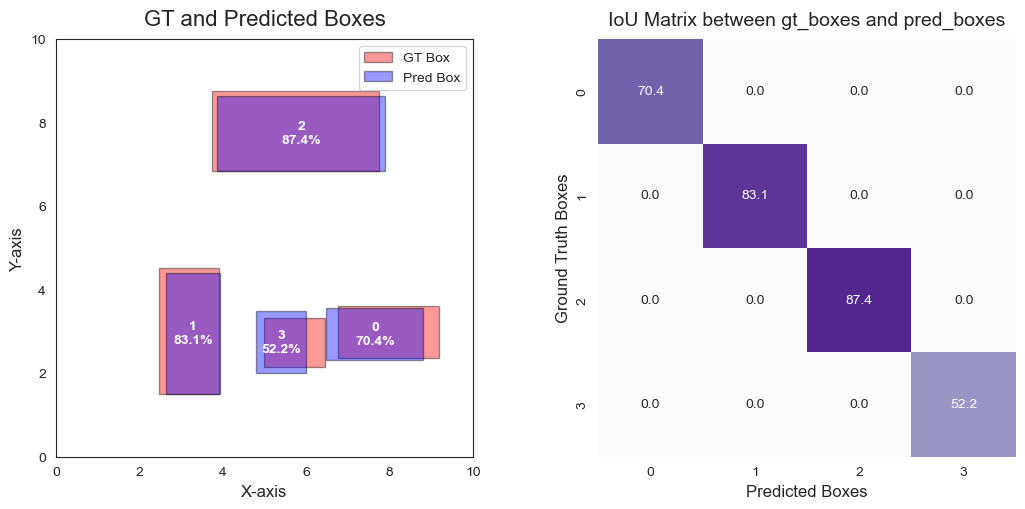

In [3]:
def visualize_ious_and_boxes(gt_boxes, pred_boxes):

    ious = np.zeros((len(gt_boxes), len(pred_boxes)))
    for i, gt in enumerate(gt_boxes):
        for j, pred in enumerate(pred_boxes[:, :4]):
            ious[i, j] = iou(gt, pred)
    ious_percent = ious * 100  # Convert IoU values to percentages

    sns.set_style("white")  # Set clean background style

    # Create the figure and subplots
    fig, axes = plt.subplots(1, 2, figsize=(12, 6), gridspec_kw={'width_ratios': [1, 1]})

    # Left plot: Ground truth and predicted boxes
    ax1 = axes[0]
    ax1.set_xlim(0, 10)
    ax1.set_ylim(0, 10)
    ax1.set_aspect('equal')
    ax1.set_title("GT and Predicted Boxes", fontsize=16, pad=10)
    ax1.set_xlabel("X-axis", fontsize=12)
    ax1.set_ylabel("Y-axis", fontsize=12)

    for gt in gt_boxes:
        y, x, h, w = gt
        ax1.add_patch(plt.Rectangle((x, y), w, h, linewidth=1, edgecolor='black', facecolor='red', alpha=0.4, label='GT Box'))
    for j, pred in enumerate(pred_boxes):
        y, x, h, w, _ = pred
        ax1.add_patch(plt.Rectangle((x, y), w, h, linewidth=1, edgecolor='black', facecolor='blue', alpha=0.4, label='Pred Box'))
        max_iou = np.max(ious[:, j]) * 100
        ax1.text(x + w / 2, y + h / 2, f"{j}\n{max_iou:.1f}%", color="white", ha="center", va="center", fontsize=10, weight="bold")

    handles, labels = ax1.get_legend_handles_labels()
    unique_handles_labels = {label: handle for handle, label in zip(handles, labels)}
    ax1.legend(unique_handles_labels.values(), unique_handles_labels.keys(), loc='upper right', fontsize=10)

    # Right plot: IoU heatmap
    ax2 = axes[1]
    sns.heatmap(ious_percent, annot=True, fmt=".1f", cmap="Purples", vmin=0, vmax=100, ax=ax2, cbar=False)
    ax2.set_aspect('equal')
    ax2.set_title("IoU Matrix between gt_boxes and pred_boxes", fontsize=14, pad=10)
    ax2.set_xlabel("Predicted Boxes", fontsize=12)
    ax2.set_ylabel("Ground Truth Boxes", fontsize=12)

    # Adjust layout
    fig.subplots_adjust(left=0.1, right=0.9, top=0.9, bottom=0.1, wspace=0.3)
    plt.show()


# Visualize IoUs
visualize_ious_and_boxes(gt_boxes, pred_boxes)

In [4]:
class FocalLoss(Module):
    def __init__(self, gamma=2.0, reduction='mean'):
        super().__init__()
        # Store gamma as a non-trainable parameter
        self.gamma = Parameter(torch.tensor(gamma), requires_grad=False)
        self.reduction = reduction

    def forward(self, preds, targets):
        # Compute p_t
        p_t = torch.where(targets == 1, preds, 1 - preds)

        # Compute the focal term (1 - p_t)^gamma
        focal_factor = (1.0 - p_t).pow(self.gamma)

        # Apply focal weighting to the cross-entropy loss: -log(p_t)
        focal_loss = -focal_factor * torch.log(p_t + 1e-7)  # +1e-7 to avoid log(0)

        # Reduction: 'mean' or 'sum' (no reduction => 'none')
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

# Focal Loss Example
logits = torch.tensor([0.1, 0.5, 0.9, 0.3], dtype=torch.float32)
targets = torch.tensor([0, 1, 1, 0], dtype=torch.float32)

focal_loss = FocalLoss()
loss = focal_loss(logits, targets)
print(f"Focal Loss: {loss.item():.4f}")

Focal Loss: 0.0519


### 2. Average Prediction

Implement a function that computes the average precision. Use the point interpolation method (see updated lecture slides).
Compute the AP for `scored_detections`.


In [6]:
scored_detections = [[78.4, True], [72.4, True], [65.1, False], [63.6, True], [63.4, True], [57.6, False], [54.6, False], [23.2, False], [12.2, True]]

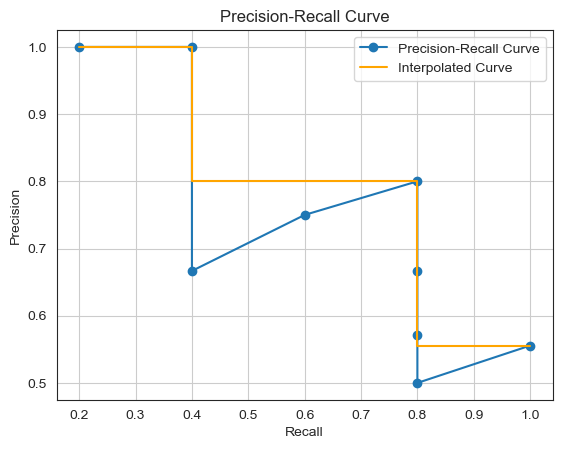

0.6311111111111112


In [7]:
def average_precision(scored_detections, num_ground_truths, sorted=False, plot=False):

    # Sort detections by score in descending order if not already sorted
    if not sorted:
        scored_detections.sort(key=lambda x: x[0], reverse=True)

    # Calculate precision and recall at each detection
    tp = 0
    fp = 0
    pr_curve = []

    for score, is_correct in scored_detections:
        if is_correct:
            tp += 1
        else:
            fp += 1

        fn = num_ground_truths - tp
        precision = tp / (tp + fp)
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        pr_curve.append((recall, precision))

    # Sort the curve by recall (ascending)
    pr_curve.sort(key=lambda x: x[0])

    # Interpolate and integrate the curve
    max_p = 0.0
    last_r = 1.0
    integrated_area = 0.0
    interpolated_points = []

    # Traverse from high recall to low (reverse)
    for r, p in reversed(pr_curve):
        integrated_area += (last_r - r) * max_p
        max_p = max(max_p, p)
        last_r = r
        interpolated_points.append((r, max_p))

    interpolated_points = np.array(interpolated_points)

    # Plot the precision-recall curve if requested
    if plot:
        recalls = [r for r, _ in pr_curve]
        precisions = [p for _, p in pr_curve]

        plt.figure()
        plt.plot(recalls, precisions, marker='o', label='Precision-Recall Curve')
        plt.step(interpolated_points[:, 0], interpolated_points[:, 1], where='post',
                 color='orange', label='Interpolated Curve')
        plt.xlabel('Recall')
        plt.ylabel('Precision')
        plt.title('Precision-Recall Curve')
        plt.legend()
        plt.grid(True)
        plt.show()

    return integrated_area

print(average_precision(scored_detections, num_ground_truths=5, plot=True))

### 3. Implement the Hungarian Loss

1. Implement a DETR detection head with 20 queries that uses the `features` tensor. Use your self-attention implementation from exercise 1 and adapt it for cross-attention.
2. Implement the hungarian loss. For simplicity, use the L1 loss as the distance (you might need to use the sigmoid function on your activations).  
   Use the Hungarian algorithm implementation from scipy.  
3. Train the cross-attention layer to match the 10 target boxes.  
**Hint:** Initializations are crucial, so check your initial predictions.


In [8]:
from scipy.optimize import linear_sum_assignment
from torchvision.ops import box_convert
from torchvision.utils import draw_bounding_boxes

query_tokens = torch.randn(20, 256)  # these go to query
feature_tokens = torch.rand(7,7,256)  # these go to keys and values

import math
import torch
from torch import nn


class TransformerDecoderLayerCrossOnly(nn.Module):
    def __init__(
        self,
        embedding_dim=48,
        hidden_dim=64,
        n_heads=4,
        device='cpu'
    ):
        super().__init__()
        self.device = device
        self.embedding_dim = embedding_dim
        self.hidden_dim = hidden_dim
        self.n_heads = n_heads
        self.head_dim = embedding_dim // n_heads

        # --- Cross-attention projections ---
        self.q_proj = nn.Linear(embedding_dim, embedding_dim, bias=False)
        self.k_proj = nn.Linear(embedding_dim, embedding_dim, bias=False)
        self.v_proj = nn.Linear(embedding_dim, embedding_dim, bias=False)

        # --- 2-layer MLP ---
        self.fc1 = nn.Linear(embedding_dim, hidden_dim, bias=True)
        self.fc2 = nn.Linear(hidden_dim, embedding_dim, bias=True)

    def layer_norm(self, x, eps=1e-6):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, unbiased=False, keepdim=True)
        return (x - mean) / torch.sqrt(var + eps)

    def cross_attention(self, query, feaure):
        B, Q_len, D = query.shape
        _, M_len, _ = feaure.shape

        # 1) Project Q from query; K, V from feature
        Q = self.q_proj(query)    # [B, Q_len, D]
        K = self.k_proj(feaure)   # [B, M_len, D]
        V = self.v_proj(feaure)   # [B, M_len, D]

        # 2) Reshape for multi-head: [B, n_heads, seq_len, head_dim]
        Q = Q.view(B, Q_len, self.n_heads, self.head_dim).permute(0, 2, 1, 3)
        K = K.view(B, M_len, self.n_heads, self.head_dim).permute(0, 2, 1, 3)
        V = V.view(B, M_len, self.n_heads, self.head_dim).permute(0, 2, 1, 3)

        # 3) Scaled dot-product attention:
        scores = torch.matmul(Q, K.transpose(-1, -2)) / math.sqrt(self.head_dim)
        attn = scores.softmax(dim=-1)
        out = torch.matmul(attn, V)

        return out.permute(0, 2, 1, 3).contiguous().view(B, Q_len, D)

    def forward(self, query_tokens, feature_tokens):
        # --- Cross-Attention ---
        cross_att_out = self.cross_attention(query_tokens, feature_tokens)
        # Residual + LN
        x = self.layer_norm(query_tokens + cross_att_out)

        # --- 2-layer MLP ---
        # fc1 -> ReLU -> fc2
        mlp_out = self.fc1(x)
        mlp_out = mlp_out.clamp(min=0)  # manual ReLU
        mlp_out = self.fc2(mlp_out)

        # Another Residual + LN
        x = self.layer_norm(x + mlp_out)

        return x

# batch_size = 1 for simplicity
query_tokens = query_tokens.unsqueeze(0)

# Flatten the 7x7 feature map
feature_tokens = feature_tokens.view(7*7, 256)
feature_tokens = feature_tokens.unsqueeze(0)

decoder_layer = TransformerDecoderLayerCrossOnly(
    embedding_dim=256,
    hidden_dim=512,
    n_heads=8,
    device='cpu'
)

decoded_queries = decoder_layer(query_tokens, feature_tokens)

print(decoded_queries.size())

torch.Size([1, 20, 256])


Predicted Boxes: torch.Size([20, 4])
Confidence Scores: torch.Size([20, 1])


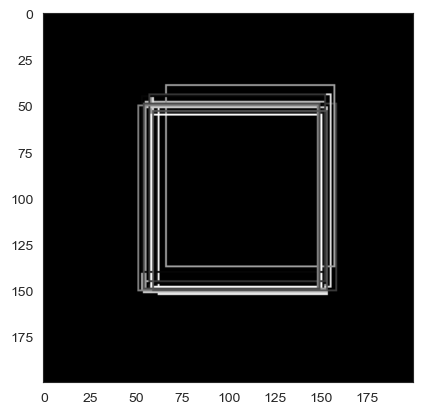

In [9]:
class DETRHead(nn.Module):
    def __init__(self, in_dim=256, hidden_dim=256):
        super().__init__()
        self.fc1 = nn.Linear(in_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)

        # Output layers
        self.bbox_fc = nn.Linear(hidden_dim, 4)  # => [cx, cy, w, h]
        self.confidence_fc = nn.Linear(hidden_dim, 1)  # => confidence score

    def forward(self, x):
        # Simple 2-layer MLP
        x = self.fc1(x).clamp(min=0)
        x = self.fc2(x).clamp(min=0)

        pred_boxes = torch.sigmoid(self.bbox_fc(x))   # bounding box in [0,1]
        confidence_scores = torch.sigmoid(self.confidence_fc(x))  # confidence in [0,1]

        return pred_boxes, confidence_scores

# Example usage
bbox_head = DETRHead(256, 256)
decoded_queries = torch.randn(20, 256)  # Simulated input for 20 queries
pred_boxes, confidence_scores = bbox_head(decoded_queries)

print("Predicted Boxes:", pred_boxes.size())  # Should be [20, 4]
print("Confidence Scores:", confidence_scores.size())  # Should be [20, 1]



plt.imshow(draw_bounding_boxes(torch.zeros(3, 200, 200, dtype=torch.uint8),
                               200 * box_convert(pred_boxes, 'cxcywh', 'xyxy'),
                               colors=["rgb({},{},{})".format(*[int(255 * alpha)] * 3) for alpha in ((confidence_scores - confidence_scores.min()) / (confidence_scores.max() - confidence_scores.min()))]
                               ).permute(1, 2, 0))

In [10]:
def l1_loss(pred_boxes, target_boxes):
    return torch.abs(pred_boxes - target_boxes).mean()

def hungarian_loss(pred_boxes, target_boxes, class_logits):

    if len(pred_boxes) == 0:
        raise ValueError
    if len(target_boxes) == 0:
        raise ValueError
    if len(class_logits) == 0:
        raise ValueError
    if len(pred_boxes) != len(class_logits):
        raise ValueError
    if len(pred_boxes) < len(target_boxes):
        raise ValueError



    loss_matrix = torch.zeros((pred_boxes.shape[0], pred_boxes.shape[0]))
    for i, pred_box in enumerate(pred_boxes):
        for j in range(pred_boxes.shape[0]):
            try:
                target_box = target_boxes[j]
                loss_matrix[i, j] = l1_loss(pred_box, target_box) - class_logits[i]
            except IndexError:
                loss_matrix[i, j] = class_logits[i]

    row_indices, col_indices = linear_sum_assignment(loss_matrix.detach().numpy())
    return loss_matrix[row_indices, col_indices].sum()

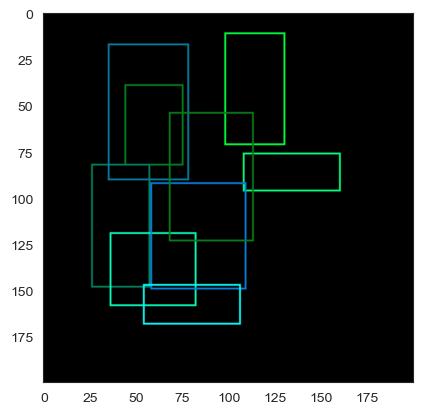

In [11]:
c = 0.2+torch.rand(10, 2)*0.6
s = 0.1+torch.rand(10, 2)*0.3
targets = torch.cat([c,s], dim=1)
plt.imshow(draw_bounding_boxes(torch.zeros(3, 200,200), 200*box_convert(targets, 'cxcywh', 'xyxy')).permute(1,2,0))

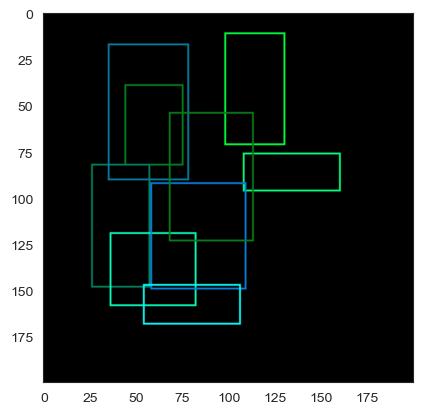

In [12]:
import torchvision
plt.imshow(torchvision.utils.draw_bounding_boxes(torch.zeros(3, 200,200), 200*box_convert(targets, 'cxcywh', 'xyxy')).permute(1,2,0))

### 4. Object Detector Implementation and Training

#### Detector Implementation
Implement one of the following object detectors (or a combination of them): FCOS, CenterNet or RetinaNet.  
FCOS: https://openaccess.thecvf.com/content_ICCV_2019/papers/Tian_FCOS_Fully_Convolutional_One-Stage_Object_Detection_ICCV_2019_paper.pdf    
CenterNet: https://arxiv.org/pdf/1904.08189   
RetinaNet: https://arxiv.org/pdf/1708.02002v2.pdf  
Use a ResNet18 as a backbone. Don't forget to implement the FPN. You are free to use all of PyTorch (including `torch.nn`) and torchvision.

#### Detector Training
Train the detector on MS COCO selection.   
You can download the images here: http://images.cocodataset.org/zips/val2017.zip   
Upload your predictions on the test set to StudIP in the format defined below (`ex2_groupX_predictions.json`).  
**Note:** This is a fairly small training dataset of only 2000 images for detection, so don't expect state-of-the-art performance.

In [14]:
from torchvision.models import resnet18, ResNet18_Weights
from torch import nn

resnet = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)


#!wget http://images.cocodataset.org/zips/val2017.zip
#!unzip val2017.zip

In [15]:
# If you want to see the dataset length for debugging,
# you can keep this cell. But do NOT rely on CocoDetection directly
# in your training code.

import torch
from torchvision.transforms import v2
from torchvision.datasets import CocoDetection

subset_name = 'val2017'

img_size = 224
transforms = v2.Compose([
    v2.ToImage(),
    v2.Resize(img_size, antialias=True),
    v2.CenterCrop(img_size),
    v2.ToDtype(torch.float32, scale=True),
])

# Optional debug dataset calls—**not** used in final training
coco = CocoDetection( f'val2017', annFile=f'instances_course_train.json', transforms=transforms)
coco_test = CocoDetection( f'val2017', annFile=f'instances_course_test_no_annotations.json', transforms=transforms)
len(coco), len(coco_test)


loading annotations into memory...
Done (t=0.13s)
creating index...
index created!
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!


(2000, 361)

In [19]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models import resnet18
from torchvision.ops import FeaturePyramidNetwork
from torch.utils.data import DataLoader
from pycocotools.coco import COCO
import torchvision.transforms as T
from tqdm import tqdm
import os
from PIL import Image
from torchvision.ops import sigmoid_focal_loss
from pycocotools.coco import COCO

# Define the multi-level FCOS loss function
def fcos_loss_multi_level(cls_outs, reg_outs, center_outs, targets, strides, image_size=(224, 224)):
    device = cls_outs[0].device
    N = cls_outs[0].shape[0]  # Batch size
    C = cls_outs[0].shape[1]  # Number of classes

    total_cls_loss = 0.0
    total_reg_loss = 0.0
    total_cent_loss = 0.0

    for cls_out, reg_out, center_out, stride in zip(cls_outs, reg_outs, center_outs, strides):
        N, C, H, W = cls_out.shape

        # Flatten the outputs for easier processing
        cls_out_flat = cls_out.permute(0, 2, 3, 1).reshape(-1, C)         # [N*H*W, C]
        reg_out_flat = reg_out.permute(0, 2, 3, 1).reshape(-1, 4)         # [N*H*W, 4]
        center_out_flat = center_out.permute(0, 2, 3, 1).reshape(-1)     # [N*H*W]

        # Initialize target tensors
        cls_targets = torch.zeros_like(cls_out_flat, device=device)       # [N*H*W, C]
        reg_targets = torch.zeros_like(reg_out_flat, device=device)       # [N*H*W, 4]
        center_targets = torch.zeros_like(center_out_flat, device=device) # [N*H*W]
        pos_mask = torch.zeros(cls_out_flat.shape[0], dtype=torch.bool, device=device)  # [N*H*W]

        stride_h = image_size[0] / H
        stride_w = image_size[1] / W

        for b, tdict in enumerate(targets):
            boxes = tdict["boxes"]    # [num_boxes, 4]
            labels = tdict["labels"]  # [num_boxes]

            for box, label in zip(boxes, labels):
                x0, y0, bw, bh = box
                x1 = x0 + bw
                y1 = y0 + bh

                # Skip invalid boxes
                if bw <= 0 or bh <= 0:
                    continue

                fx0 = int(x0 // stride_w)
                fx1 = int(x1 // stride_w)
                fy0 = int(y0 // stride_h)
                fy1 = int(y1 // stride_h)

                # Clamp to feature map dimensions
                fx0 = max(0, min(fx0, W - 1))
                fx1 = max(0, min(fx1, W - 1))
                fy0 = max(0, min(fy0, H - 1))
                fy1 = max(0, min(fy1, H - 1))

                for yy in range(fy0, fy1 + 1):
                    for xx in range(fx0, fx1 + 1):
                        idx = b * (H * W) + yy * W + xx
                        pos_mask[idx] = True
                        if label < C:
                            cls_targets[idx, label] = 1.0

                        px = xx * stride_w
                        py = yy * stride_h
                        l = px - x0
                        r = x1 - px
                        t_ = py - y0
                        b_ = y1 - py

                        # Clamp distances to avoid negative values
                        l = max(l, 0.0)
                        r = max(r, 0.0)
                        t_ = max(t_, 0.0)
                        b_ = max(b_, 0.0)

                        reg_targets[idx] = torch.tensor([l, t_, r, b_], device=device)

                        # Compute centerness
                        if (l < 1e-9 or r < 1e-9 or t_ < 1e-9 or b_ < 1e-9):
                            center_targets[idx] = 0.0
                        else:
                            num_lr = min(l, r) * min(t_, b_)
                            den_lr = max(l, r) * max(t_, b_)
                            cval = torch.sqrt(num_lr / (den_lr + 1e-7))
                            center_targets[idx] = cval

        # --- Classification Loss (Focal Loss) ---
        cls_loss = sigmoid_focal_loss(
            cls_out_flat,    # [N*H*W, C] raw logits
            cls_targets,     # [N*H*W, C] one-hot targets
            gamma=2.0,
            reduction="sum"
        )

        # --- Regression + Centerness (Only Positive Samples) ---
        pos_inds = pos_mask.nonzero(as_tuple=False).squeeze(1)  # Indices of positive samples
        if len(pos_inds) > 0:
            # Regression Loss (L1)
            pred_reg = reg_out_flat[pos_inds]          # [num_pos, 4]
            tgt_reg = reg_targets[pos_inds]           # [num_pos, 4]
            reg_loss = F.l1_loss(pred_reg, tgt_reg, reduction="sum")

            # Centerness Loss (Binary Cross Entropy)
            pred_center = center_out_flat[pos_inds]    # [num_pos]
            tgt_center = center_targets[pos_inds]     # [num_pos]
            cent_loss = F.binary_cross_entropy_with_logits(
                pred_center, tgt_center, reduction="sum"
            )
        else:
            reg_loss = torch.tensor(0.0, device=device)
            cent_loss = torch.tensor(0.0, device=device)

        # Combine losses for this level
        total_cls_loss += cls_loss
        total_reg_loss += reg_loss
        total_cent_loss += cent_loss

    # Combine all losses across all levels and normalize by batch size
    total_loss = (total_cls_loss + total_reg_loss + total_cent_loss) / N

    # Check for NaNs
    assert not torch.isnan(total_loss), "Total loss is NaN."

    return total_loss

# Model Definitions

class ResNet18FPN(nn.Module):
    def __init__(self):
        super().__init__()
        backbone = resnet18(pretrained=True)
        self.stage1 = nn.Sequential(*list(backbone.children())[:5])  # Conv1 + BN + ReLU + MaxPool
        self.stage2 = nn.Sequential(*list(backbone.children())[5])   # Layer1
        self.stage3 = nn.Sequential(*list(backbone.children())[6])   # Layer2
        self.stage4 = nn.Sequential(*list(backbone.children())[7])   # Layer3

        # Feature Pyramid Network expects feature maps from different stages
        self.fpn = FeaturePyramidNetwork([64, 128, 256, 512], 256)

    def forward(self, x):
        c1 = self.stage1(x)  # [B,64,H1,W1]
        c2 = self.stage2(c1) # [B,128,H2,W2]
        c3 = self.stage3(c2) # [B,256,H3,W3]
        c4 = self.stage4(c3) # [B,512,H4,W4]

        features = {"c1": c1, "c2": c2, "c3": c3, "c4": c4}
        fpn_features = self.fpn(features)  # Outputs from FPN layers

        return fpn_features

class FCOSHead(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.num_classes = num_classes
        self.cls_head = self._make_head()
        self.reg_head = self._make_head()
        self.centerness_head = self._make_head()
        self.cls_score = nn.Conv2d(256, num_classes, kernel_size=3, padding=1)
        self.bbox_pred = nn.Conv2d(256, 4, kernel_size=3, padding=1)
        self.centerness = nn.Conv2d(256, 1, kernel_size=3, padding=1)

    def _make_head(self):
        layers = []
        for _ in range(4):
            layers.append(nn.Conv2d(256, 256, kernel_size=3, padding=1))
            layers.append(nn.ReLU(inplace=True))
        return nn.Sequential(*layers)

    def forward(self, features):
        cls_outputs = []
        reg_outputs = []
        centerness_outputs = []
        for feat in features.values():
            c = self.cls_head(feat)          # [B,256,H,W]
            r = self.reg_head(feat)          # [B,256,H,W]
            ce = self.centerness_head(feat)  # [B,256,H,W]
            cls_outputs.append(self.cls_score(c))          # [B,num_classes,H,W]
            reg_outputs.append(self.bbox_pred(r))          # [B,4,H,W]
            centerness_outputs.append(self.centerness(ce)) # [B,1,H,W]

        return cls_outputs, reg_outputs, centerness_outputs

class FCOS(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.backbone = ResNet18FPN()
        self.head = FCOSHead(num_classes)

    def forward(self, x):
        fpn_features = self.backbone(x)
        cls_outs, reg_outs, centerness_outs = self.head(fpn_features)
        return cls_outs, reg_outs, centerness_outs

def load_coco_dataset(ann_file, img_dir, transform):
    coco = COCO(ann_file)

    class CocoDataset(torch.utils.data.Dataset):
        def __init__(self, coco, img_dir, transform):
            self.coco = coco
            self.ids = list(coco.imgs.keys())
            self.img_dir = img_dir
            self.transform = transform

        def __len__(self):
            return len(self.ids)

        def __getitem__(self, idx):
            img_id = self.ids[idx]
            ann_ids = self.coco.getAnnIds(imgIds=img_id)
            anns = self.coco.loadAnns(ann_ids)

            img_info = self.coco.loadImgs(img_id)[0]
            img_path = os.path.join(self.img_dir, img_info['file_name'])
            img = Image.open(img_path).convert('RGB')

            boxes = []
            labels = []
            for ann in anns:
                # Each ann['bbox'] = [x, y, w, h]
                boxes.append(ann['bbox'])
                labels.append(ann['category_id'])

            target = {
                "boxes": torch.tensor(boxes, dtype=torch.float32),
                "labels": torch.tensor(labels, dtype=torch.int64)
            }

            if self.transform:
                img = self.transform(img)

            return img, target

    return CocoDataset(coco, img_dir, transform)

def collate_fn(batch):
    images = [b[0] for b in batch]
    targets = [b[1] for b in batch]
    return images, targets

# Training Loop

def train_detector_multi_level(model, dataloader, optimizer, device, strides, image_size=(224,224)):
    model.train()
    total_loss = 0.0

    # Initialize GradScaler for AMP if needed
    scaler = torch.cuda.amp.GradScaler(enabled=True)

    for images, targets in tqdm(dataloader, desc="Training"):
        # Move images to device and stack into a batch tensor
        images = torch.stack(images).to(device, non_blocking=True)

        # Move targets to device
        for t in targets:
            t["boxes"] = t["boxes"].to(device, non_blocking=True)
            t["labels"] = t["labels"].to(device, non_blocking=True)

        optimizer.zero_grad()

        # Optional mixed-precision
        with torch.cuda.amp.autocast(enabled=True):
            cls_outs, reg_outs, centerness_outs = model(images)  # Lists per FPN level
            loss = fcos_loss_multi_level(cls_outs, reg_outs, centerness_outs, targets, strides=strides, image_size=image_size)

        # Scale the loss and perform backpropagation
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()

    avg_loss = total_loss / len(dataloader)
    return avg_loss

# Example Test Function

def test_fcos_loss_multi_level():
    # Define strides corresponding to each FPN level
    strides = [8, 16, 32, 64]
    image_size = (224, 224)

    # Fake model outputs for 4 FPN levels
    cls_outs = [
        torch.randn(1, 80, 28, 28),  # Level 1 (stride 8)
        torch.randn(1, 80, 14, 14),  # Level 2 (stride 16)
        torch.randn(1, 80, 7, 7),    # Level 3 (stride 32)
        torch.randn(1, 80, 4, 4)     # Level 4 (stride 64)
    ]

    reg_outs = [
        torch.abs(torch.randn(1, 4, 28, 28)),  # Level 1
        torch.abs(torch.randn(1, 4, 14, 14)),  # Level 2
        torch.abs(torch.randn(1, 4, 7, 7)),    # Level 3
        torch.abs(torch.randn(1, 4, 4, 4))     # Level 4
    ]

    center_outs = [
        torch.randn(1, 1, 28, 28),  # Level 1
        torch.randn(1, 1, 14, 14),  # Level 2
        torch.randn(1, 1, 7, 7),    # Level 3
        torch.randn(1, 1, 4, 4)     # Level 4
    ]

    # Define a fake target for one image with two boxes
    target = {
        "boxes": torch.tensor([
            [50, 50, 100, 100],  # [x, y, w, h]
            [120, 120, 50, 50]
        ], dtype=torch.float32),
        "labels": torch.tensor([1, 2], dtype=torch.int64)
    }
    targets = [target]

    # Compute the loss
    loss = fcos_loss_multi_level(cls_outs, reg_outs, center_outs, targets, strides=strides, image_size=image_size)
    print("Multi-level FCOS Loss:", loss.item())

# Main Function

def main():
    num_classes = 80  # MS COCO has 80 classes
    model = FCOS(num_classes)

    # Device configuration
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    model.to(device)
    print("Using device:", device)

    # Dataset and DataLoader
    ann_file = "instances_course_train.json"
    img_dir = "val2017"

    train_transform = T.Compose([
        T.Resize((224, 224)),
        T.ToTensor(),
    ])

    coco_dataset = load_coco_dataset(ann_file, img_dir, transform=train_transform)

    # Train/Validation split
    train_size = int(0.9 * len(coco_dataset))
    val_size = len(coco_dataset) - train_size
    coco_train, coco_val = torch.utils.data.random_split(coco_dataset, [train_size, val_size])

    dataloader = DataLoader(
        coco_train,
        batch_size=32,
        shuffle=True,
        collate_fn=collate_fn,
        num_workers=16,
        pin_memory=True,
        drop_last=True
    )

    # Define strides for each FPN level
    strides = [8, 16, 32, 64]  # c1, c2, c3, c4

    # Optimizer
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    # Number of epochs
    epochs = 3

    # Training loop
    for epoch in range(epochs):
        avg_loss = train_detector_multi_level(model, dataloader, optimizer, device, strides=strides, image_size=(224,224))
        print(f"[Epoch {epoch+1}/{epochs}] Avg Loss = {avg_loss:.4f}")




In [20]:
# Run the test and training
if __name__ == "__main__":
    # Run the test to ensure the loss function works correctly

    # Proceed with training
    main()

Using device: cpu
loading annotations into memory...
Done (t=0.14s)
creating index...


/var/folders/t8/58pvkh952p3c230j1hyfwh9c0000gn/T/ipykernel_31147/1985684407.py:257: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=True)


index created!


Training:   0%|          | 0/56 [00:00<?, ?it/s]


AttributeError: Can't get local object 'load_coco_dataset.<locals>.CocoDataset'